In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [2]:
VOCAB_SIZE = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Training Reviews :", len(x_train))
print("Testing Reviews  :", len(x_test))

Training Reviews : 25000
Testing Reviews  : 25000


In [3]:
print("First Review Length :", len(x_train[0]))
print("First Review Label  :", y_train[0])

First Review Length : 218
First Review Label  : 1


In [4]:
print("Maximum Review Length")

max_length = max(len(review) for review in x_train)

print(max_length)

Maximum Review Length
2494


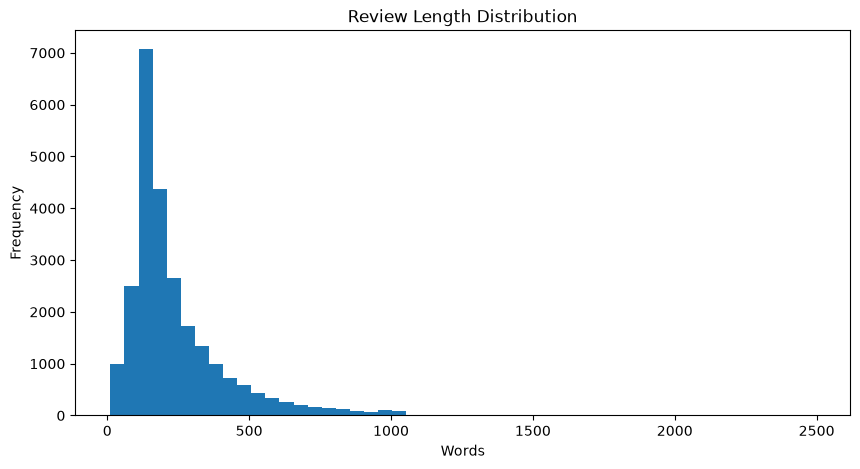

In [5]:
lengths = [len(review) for review in x_train]

plt.figure(figsize=(10,5))

plt.hist(lengths, bins=50)

plt.title("Review Length Distribution")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

In [6]:
MAX_LENGTH = 200

x_train = pad_sequences(
    x_train,
    maxlen=MAX_LENGTH
)

x_test = pad_sequences(
    x_test,
    maxlen=MAX_LENGTH
)

print(x_train.shape)
print(x_test.shape)

(25000, 200)
(25000, 200)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense

model = Sequential([
    Input(shape=(MAX_LENGTH,)),
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128
    ),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 171ms/step - accuracy: 0.7890 - loss: 0.4448 - val_accuracy: 0.8598 - val_loss: 0.3330
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 196ms/step - accuracy: 0.8978 - loss: 0.2601 - val_accuracy: 0.8724 - val_loss: 0.3064
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 67s 213ms/step - accuracy: 0.9342 - loss: 0.1822 - val_accuracy: 0.8618 - val_loss: 0.3552
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 166ms/step - accuracy: 0.9516 - loss: 0.1410 - val_accuracy: 0.8628 - val_loss: 0.4056
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 132ms/step - accuracy: 0.9654 - loss: 0.1006 - val_accuracy: 0.8432 - val_loss: 0.4068


In [10]:
loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.8475 - loss: 0.4042
Test Loss : 0.4041796922683716
Test Accuracy : 0.8474799990653992


In [11]:
model.save("../app/models/sentiment_model.h5")

print("Sentiment Model Saved Successfully!")

Sentiment Model Saved Successfully!


In [12]:
from tensorflow.keras.datasets import imdb
import joblib

word_index = imdb.get_word_index()

joblib.dump(
    word_index,
    "../app/models/imdb_word_index.pkl"
)

print("Word Index Saved Successfully!")

Word Index Saved Successfully!


In [13]:
sample_review = x_test[0].reshape(1, -1)

prediction = model.predict(sample_review)

print("Prediction Probability:", prediction[0][0])

if prediction[0][0] >= 0.5:
    print("Predicted Sentiment: Positive")
else:
    print("Predicted Sentiment: Negative")

print("Actual Label:", "Positive" if y_test[0] == 1 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
Prediction Probability: 0.26976147
Predicted Sentiment: Negative
Actual Label: Negative
